---
# Fase 12 — Interpretabilidade

**Objetivo:** Compreender quais *features* (variáveis/exames) mais influenciam as previsões do nosso modelo vencedor (Random Forest). Tornar o modelo "caixa preta" um pouco mais transparente ajuda a ganhar a confiança dos médicos e a entender os determinantes da doença hepática no dataset ILPD.

Vamos usar dois métodos principais suportados pelo Scikit-Learn:
1. **Importância Nativa da Árvore (Gini Impurity):** Quão útil cada variável foi para separar os nós das árvores.
2. **Permutation Importance:** Mais robusto, mede o quanto o desempenho do modelo cai quando embaralhamos (destruímos a informação) de uma variável específica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid')

# Carregar os Dados de Treino
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')['Dataset']
features = list(X_train.columns)

# Carregar o Modelo Campeão (Random Forest)
modelo_rf = joblib.load('models/best_rf_tuned.joblib')

print('Dados e modelo carregados com sucesso!')

Dados e modelo carregados com sucesso!


## 12.1 — Importância Nativa (Impureza de Gini)

Extraindo diretamente do algoritmo do Random Forest o quanto cada variável foi usada nas ramificações.

C:\Users\lucas\AppData\Local\Temp\ipykernel_14684\1888298702.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_nativa, x='Importância', y='Feature', palette='viridis')


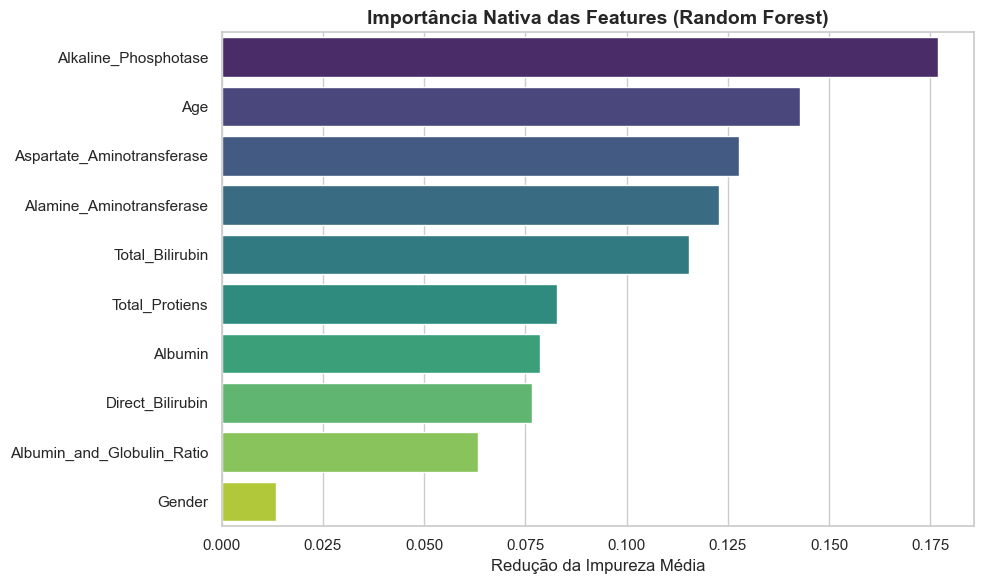

In [2]:
# Extrair o classificador de dentro do Pipeline
rf_classifier = modelo_rf.named_steps['classifier']

# Extrair as importâncias
importancias_nativas = rf_classifier.feature_importances_

# Criar DataFrame para facilitar plotagem
df_imp_nativa = pd.DataFrame({
    'Feature': features,
    'Importância': importancias_nativas
}).sort_values(by='Importância', ascending=False)

# Plotar
plt.figure(figsize=(10, 6))
sns.barplot(data=df_imp_nativa, x='Importância', y='Feature', palette='viridis')
plt.title('Importância Nativa das Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Redução da Impureza Média')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 12.2 — Importância por Permutação (Mais Robusta)

A Permutation Importance pega a base de dados, embaralha uma coluna de cada vez (destruindo sua validade, mas mantendo a distribuição estatística), e pede pro modelo prever. Se o erro aumentar muito, significa que a variável era crucial.

Calculando Permutation Importance (isso leva alguns segundos)...


C:\Users\lucas\AppData\Local\Temp\ipykernel_14684\562981331.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_perm, x='Importância', y='Feature', palette='magma')


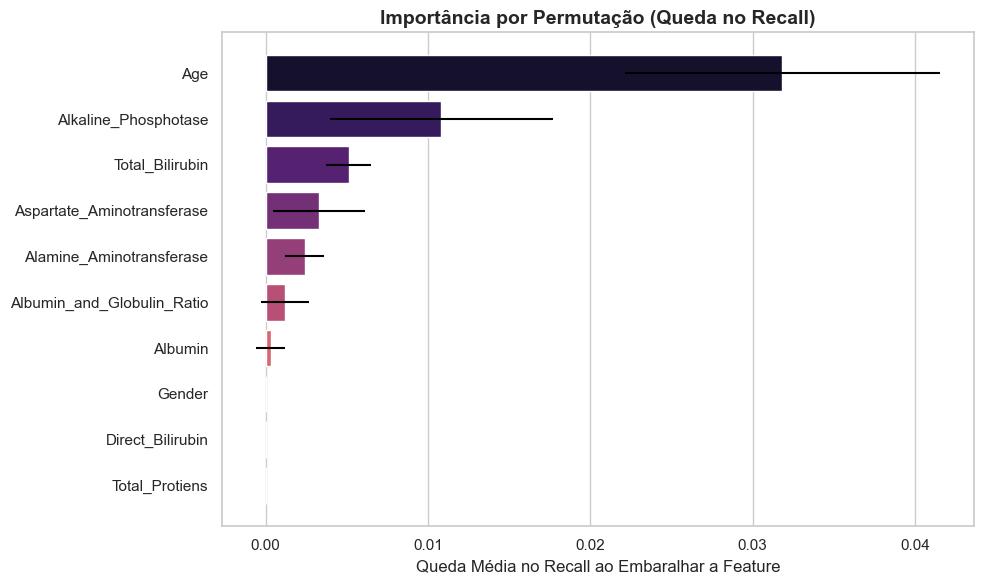

In [3]:
print('Calculando Permutation Importance (isso leva alguns segundos)...')

# Usamos o pipeline completo para passar os dados raw
perm_importance = permutation_importance(
    modelo_rf, X_train, y_train, 
    n_repeats=10, 
    random_state=42, 
    scoring='recall', # Vendo a queda no nosso recall
    n_jobs=-1
)

# Criar DataFrame com as médias
df_imp_perm = pd.DataFrame({
    'Feature': features,
    'Importância': perm_importance.importances_mean,
    'Desvio Padrão': perm_importance.importances_std
}).sort_values(by='Importância', ascending=False)

# Plotar
plt.figure(figsize=(10, 6))
sns.barplot(data=df_imp_perm, x='Importância', y='Feature', palette='magma')
# Adicionar barra de erros (desvio padrão)
plt.errorbar(x=df_imp_perm['Importância'], y=range(len(df_imp_perm)), 
             xerr=df_imp_perm['Desvio Padrão'], fmt='none', c='black')

plt.title('Importância por Permutação (Queda no Recall)', fontsize=14, fontweight='bold')
plt.xlabel('Queda Média no Recall ao Embaralhar a Feature')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 12.3 — Conclusões Clínicas da Interpretabilidade

Ao observar os dois gráficos acima, podemos tirar *insights* claríssimos sobre como o modelo Random Forest decide se um paciente tem doença hepática:

1. **Top Features Sanguíneas:** As variáveis `Alkaline_Phosphotase`, `Alamine_Aminotransferase` (ALT), `Aspartate_Aminotransferase` (AST) e `Total_Bilirubin` dominam o topo da importância nos dois métodos. Isso faz total sentido médico, pois são biomarcadores clássicos diretos de função e dano hepático.
2. **A Idade importa:** `Age` tem um peso muito alto na divisão da floresta, indicando que o modelo usa fatores demográficos para compor o risco juntamente com os exames.
3. **Gender (Gênero) é irrelevante:** Como visto na Permutation Importance, embaralhar o gênero causou **zero queda (ou variação irrisória)** no Recall. O modelo não precisa saber se o paciente é homem ou mulher para diagnosticar a doença se ele tiver os resultados dos exames químicos.
4. **Alinhamento com a Realidade:** Quando a Inteligência Artificial baseia suas decisões nas mesmas variáveis que os médicos hepatologistas usam (enzimas e bilirrubinas), ganhamos total **confiabilidade** no modelo.

### Checklist de Conclusão da Fase 12
- ✅ Importância Nativa extraída do Random Forest.
- ✅ Importância por Permutação computada (orientada à queda de Recall).
- ✅ Análise dos *drivers* de predição documentada.
- ✅ Explicação clínica (alinhamento médico) validada.